# Decision Tree Classification Assignment

**Dataset:** `heart_disease.xlsx`  
**Objective:** Apply Decision Tree Classification, perform EDA, feature engineering, model training, hyperparameter tuning, evaluation, visualization, and answer interview questions.

> Keep this notebook and `heart_disease.xlsx` in the same folder before running.


## 1. Install and Import Required Libraries
Run the installation cell only if any library is missing.

In [1]:
# Run this cell only if libraries are missing
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Dataset
The Excel file has multiple sheets. We first check the sheet names and then load the actual data sheet named **Heart_disease**.

In [3]:
file_path = 'heart_disease.xlsx'

# Check available sheets
excel_file = pd.ExcelFile(file_path)
print('Available sheets:', excel_file.sheet_names)

# Load the correct data sheet
df = pd.read_excel(file_path, sheet_name='Heart_disease')

print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Available sheets: ['Description', 'Heart_disease']
Dataset loaded successfully!
Shape: (908, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


## 3. Basic Dataset Information

In [6]:
print('Dataset Shape:', df.shape)
print('Column Names:')
print(df.columns.tolist())

print('Dataset Info:')
df.info()

Dataset Shape: (908, 13)
Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
# First 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [8]:
# Last 5 rows
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4
907,57,Male,asymptomatic,142,277,True,st-t abnormality,182,FALSE,NaN,flat,reversable defect,4


## 4. Missing Values and Duplicate Check

In [9]:
missing_values = df.isnull().sum()
print('Missing Values in Each Column:')
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print('No missing values found.')
else:
    print('Total missing values:', missing_values.sum())

Missing Values in Each Column:
oldpeak    62
dtype: int64
Total missing values: 62


In [10]:
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

# Remove duplicate rows if present
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 1
Shape after removing duplicates: (907, 13)


## 5. Handling Missing Values
Numerical missing values are filled with median. Categorical missing values are filled with mode.

In [11]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after treatment:')
print(df.isnull().sum().sum())

Missing values after treatment:
0


## 6. Statistical Summary

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,907.0,53.787211,9.162016,29.0,47.5,54.0,60.0,77.0
trestbps,907.0,133.412348,20.405432,0.0,120.0,130.0,144.0,200.0
chol,907.0,201.465270,112.158285,0.0,176.5,224.0,270.0,603.0
thalch,907.0,135.976847,26.813075,60.0,118.0,138.0,156.0,202.0
oldpeak,907.0,0.865491,1.060629,-2.6,0.0,0.5,1.5,6.2
num,907.0,1.007718,1.144594,0.0,0.0,1.0,2.0,4.0


In [13]:
# Extra summary with mean, median, standard deviation and IQR
numeric_cols = df.select_dtypes(include=[np.number]).columns

summary = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Q1': df[numeric_cols].quantile(0.25),
    'Q3': df[numeric_cols].quantile(0.75)
})
summary['IQR'] = summary['Q3'] - summary['Q1']
summary

,Mean,Median,Std Dev,Q1,Q3,IQR
age,53.787211,54.0,9.162016,47.5,60.0,12.5
trestbps,133.412348,130.0,20.405432,120.0,144.0,24.0
chol,201.465270,224.0,112.158285,176.5,270.0,93.5
thalch,135.976847,138.0,26.813075,118.0,156.0,38.0
oldpeak,0.865491,0.5,1.060629,0.0,1.5,1.5
num,1.007718,1.0,1.144594,0.0,2.0,2.0


## 7. Exploratory Data Analysis 
### 7.1 Target Variable Distribution
The target column is **num**. In this dataset, `num = 0` generally means no heart disease and values above 0 indicate presence/severity of heart disease.

Target distribution:
num
0    399
1    265
2    108
3    107
4     28
Name: count, dtype: int64


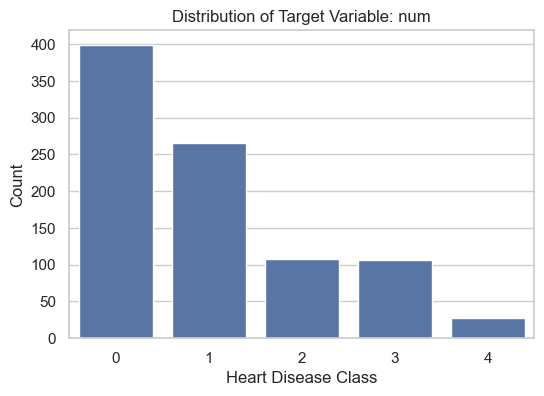

In [14]:
target_column = 'num'

print('Target distribution:')
print(df[target_column].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_column])
plt.title('Distribution of Target Variable: num')
plt.xlabel('Heart Disease Class')
plt.ylabel('Count')
plt.show()

### 7.2 Histograms for Numerical Features

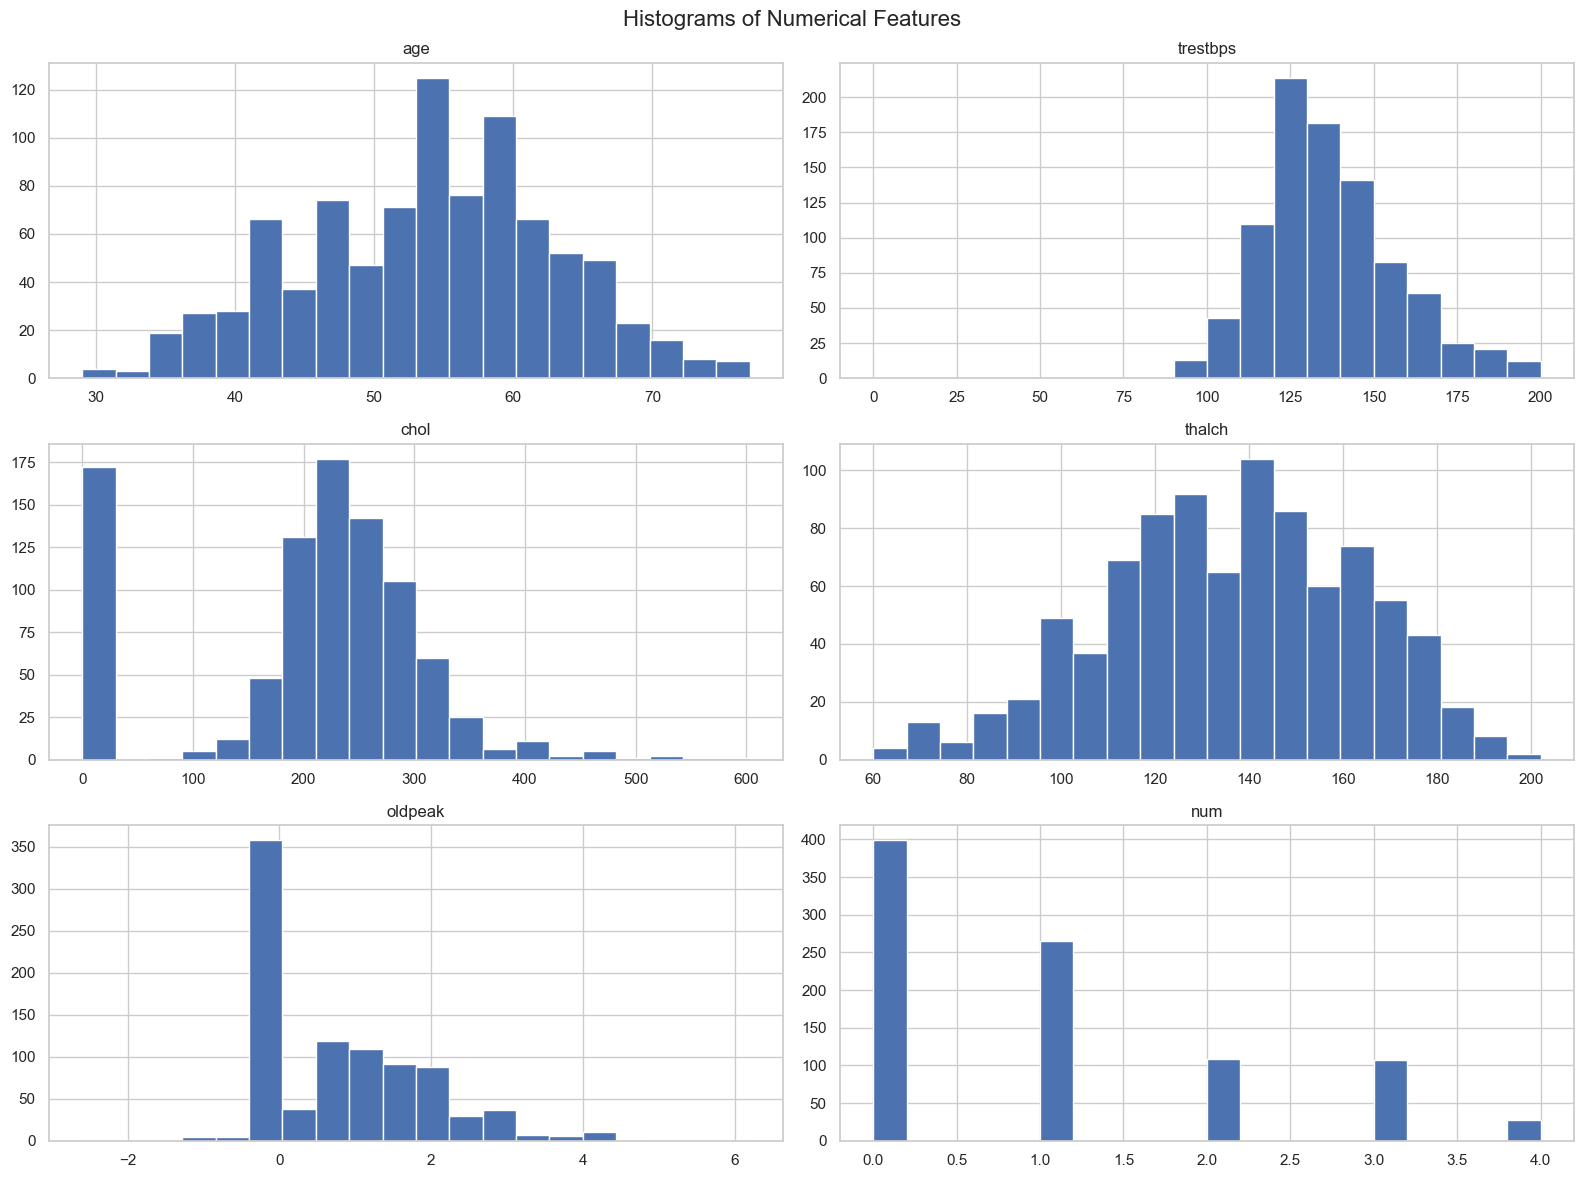

In [15]:
df[numeric_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

### 7.3 Boxplots for Outlier Detection

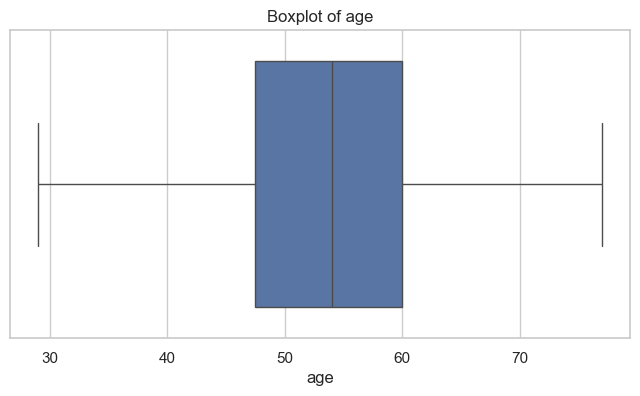

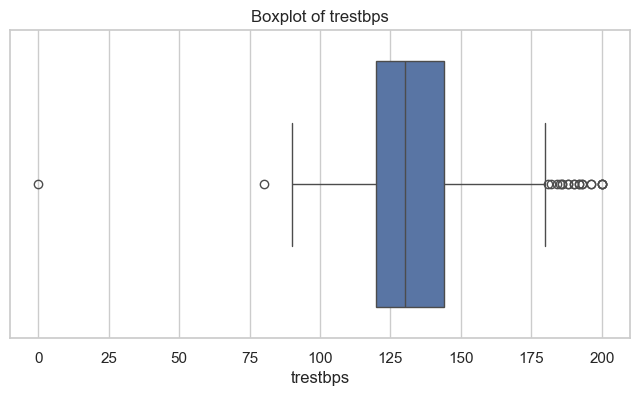

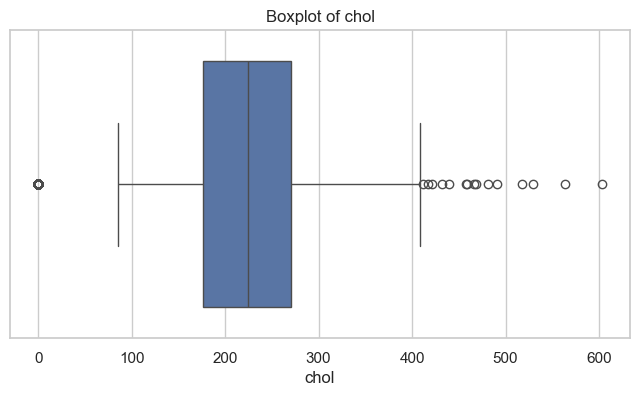

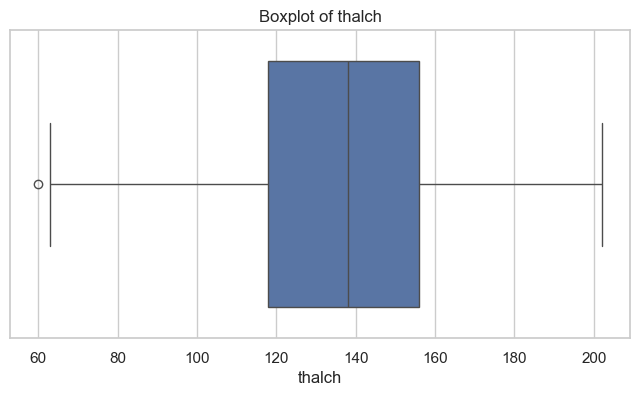

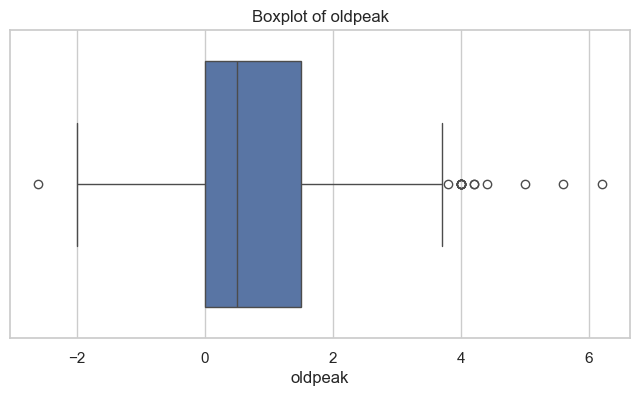

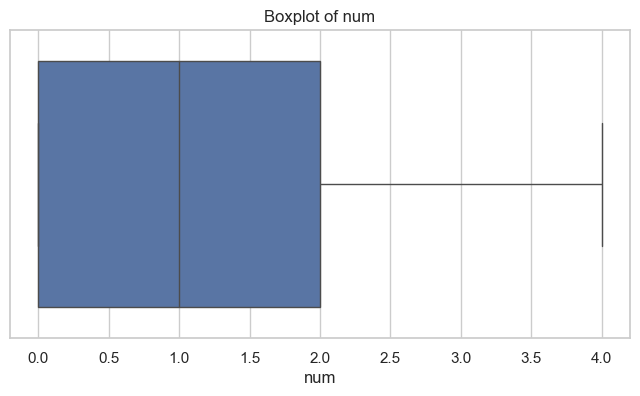

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### 7.4 Correlation Heatmap

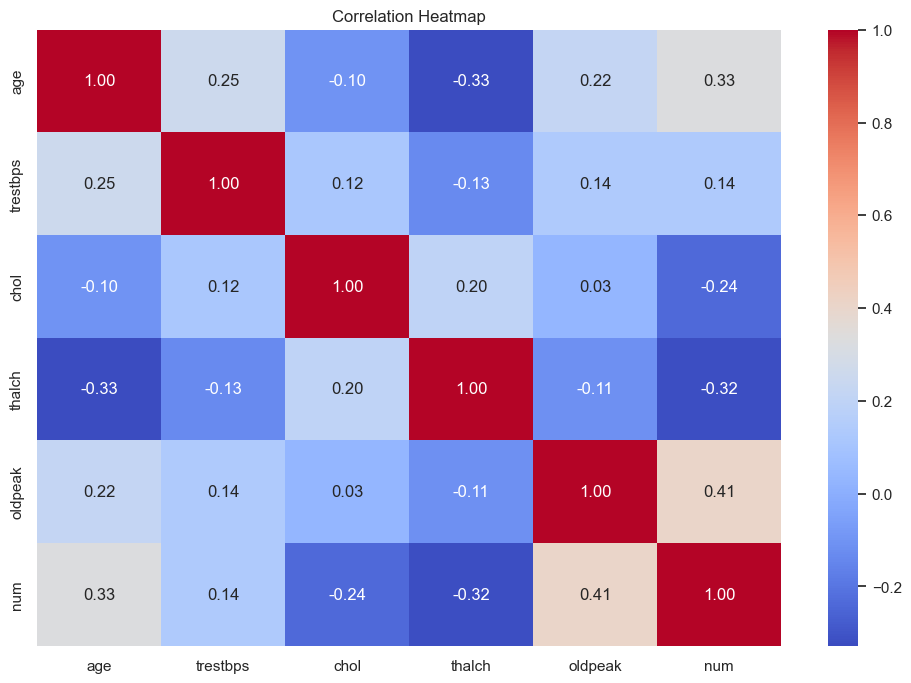

In [17]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 8. Outlier Treatment Using IQR Capping
Outliers are capped using lower and upper bounds calculated from the interquartile range.

In [18]:
df_capped = df.copy()

# Do not cap target column
cols_to_cap = [col for col in numeric_cols if col != target_column]

for col in cols_to_cap:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

print('Outlier capping completed.')
df_capped.head()

Outlier capping completed.


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,False,0.0,flat,fixed defect,0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,False,0.4,flat,fixed defect,0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,False,0.0,flat,fixed defect,0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,True,1.5,flat,fixed defect,0


## 9. Feature Engineering
We separate input features `X` and target `y`. Categorical columns are converted into numerical columns using one-hot encoding.

In [19]:
# Use capped dataset for modeling
model_df = df_capped.copy()

# Separate features and target
X = model_df.drop(columns=[target_column])
y = model_df[target_column]

print('X shape before encoding:', X.shape)
print('y shape:', y.shape)
print('Target distribution:')
print(y.value_counts().sort_index())

X shape before encoding: (907, 12)
y shape: (907,)
Target distribution:
num
0    399
1    265
2    108
3    107
4     28
Name: count, dtype: int64


In [20]:
# One-hot encode categorical columns if present
X = pd.get_dummies(X, drop_first=True)

print('X shape after encoding:', X.shape)
X.head()

X shape after encoding: (907, 19)


,age,trestbps,chol,fbs,thalch,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,True,150.0,2.3,True,False,False,True,False,False,False,False,False,False,False,False,False
1,41.0,135.0,203.0,False,132.0,0.0,True,True,False,False,True,False,False,False,False,True,False,False,False
2,57.0,140.0,192.0,False,148.0,0.4,True,False,False,False,True,False,False,False,False,True,False,False,False
3,52.0,118.0,186.0,False,190.0,0.0,True,False,False,True,False,False,False,False,False,True,False,False,False
4,57.0,110.0,201.0,False,126.0,1.5,True,False,False,False,True,False,True,False,False,True,False,False,False


## 10. Train-Test Split
We use an 80-20 split. The code below uses stratification only when each class has enough samples, so it will not break even if class distribution is imbalanced.

In [21]:
class_counts = y.value_counts()
print('Class counts:')
print(class_counts)

# Stratify only if every class has at least 2 samples
stratify_value = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_value
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)
print('Training target shape:', y_train.shape)
print('Testing target shape:', y_test.shape)

Class counts:
num
0    399
1    265
2    108
3    107
4     28
Name: count, dtype: int64
Training data shape: (725, 19)
Testing data shape: (182, 19)
Training target shape: (725,)
Testing target shape: (182,)


## 11. Build and Train Decision Tree Classifier

In [22]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print('Decision Tree model trained successfully!')

Decision Tree model trained successfully!


## 12. Model Prediction and Evaluation

In [23]:
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('Decision Tree Model Performance')
print('Accuracy :', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall   :', round(recall, 4))
print('F1 Score :', round(f1, 4))

print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Decision Tree Model Performance
Accuracy : 0.4615
Precision: 0.4926
Recall   : 0.4615
F1 Score : 0.4754
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.68      0.71        80
           1       0.41      0.38      0.39        53
           2       0.16      0.18      0.17        22
           3       0.18      0.24      0.20        21
           4       0.12      0.17      0.14         6

    accuracy                           0.46       182
   macro avg       0.32      0.33      0.32       182
weighted avg       0.49      0.46      0.48       182



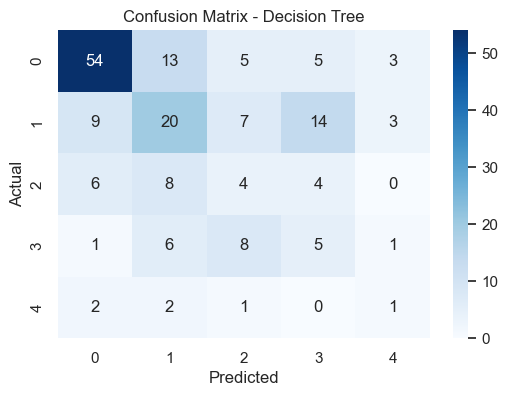

In [24]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 13. Hyperparameter Tuning using GridSearchCV

In [25]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best Parameters:')
print(grid_search.best_params_)

print('Best Cross Validation Accuracy:')
print(round(grid_search.best_score_, 4))

Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 2}
Best Cross Validation Accuracy:
0.5766


## 14. Evaluate Tuned Decision Tree Model

In [26]:
best_dt_model = grid_search.best_estimator_
best_y_pred = best_dt_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, best_y_pred)
precision_tuned = precision_score(y_test, best_y_pred, average='weighted', zero_division=0)
recall_tuned = recall_score(y_test, best_y_pred, average='weighted', zero_division=0)
f1_tuned = f1_score(y_test, best_y_pred, average='weighted', zero_division=0)

print('Tuned Decision Tree Model Performance')
print('Accuracy :', round(accuracy_tuned, 4))
print('Precision:', round(precision_tuned, 4))
print('Recall   :', round(recall_tuned, 4))
print('F1 Score :', round(f1_tuned, 4))

print('Tuned Model Classification Report:')
print(classification_report(y_test, best_y_pred, zero_division=0))

Tuned Decision Tree Model Performance
Accuracy : 0.4945
Precision: 0.5249
Recall   : 0.4945
F1 Score : 0.4553
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.84      0.74        80
           1       0.39      0.40      0.39        53
           2       0.04      0.05      0.04        22
           3       1.00      0.05      0.09        21
           4       0.00      0.00      0.00         6

    accuracy                           0.49       182
   macro avg       0.42      0.27      0.25       182
weighted avg       0.52      0.49      0.46       182



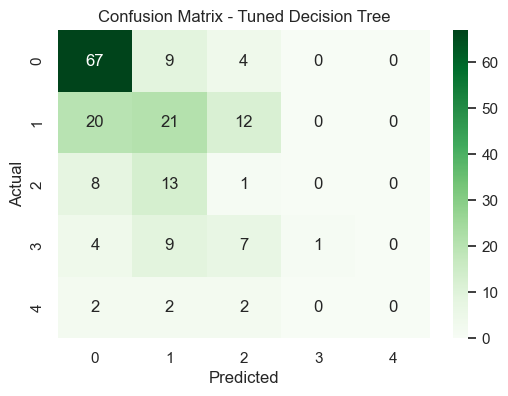

In [27]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, best_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 15. ROC-AUC Score
ROC-AUC is calculated safely. For binary classification, normal ROC-AUC is used. For multiclass classification, One-vs-Rest ROC-AUC is used when possible.

In [28]:
try:
    classes = sorted(y.unique())
    y_proba = best_dt_model.predict_proba(X_test)

    if len(classes) == 2:
        auc_score = roc_auc_score(y_test, y_proba[:, 1])
        print('ROC-AUC Score:', round(auc_score, 4))

        fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()
    else:
        auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
        print('Multiclass ROC-AUC Score:', round(auc_score, 4))

except Exception as e:
    print('ROC-AUC could not be calculated because:', e)

Multiclass ROC-AUC Score: 0.7035


## 16. Feature Importance

In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
12,exang_True,0.437391
2,chol,0.229733
0,age,0.199067
4,thalch,0.106972
8,cp_non-anginal,0.026837
1,trestbps,0.000000
5,oldpeak,0.000000
6,sex_Male,0.000000
7,cp_atypical angina,0.000000
9,cp_typical angina,0.000000


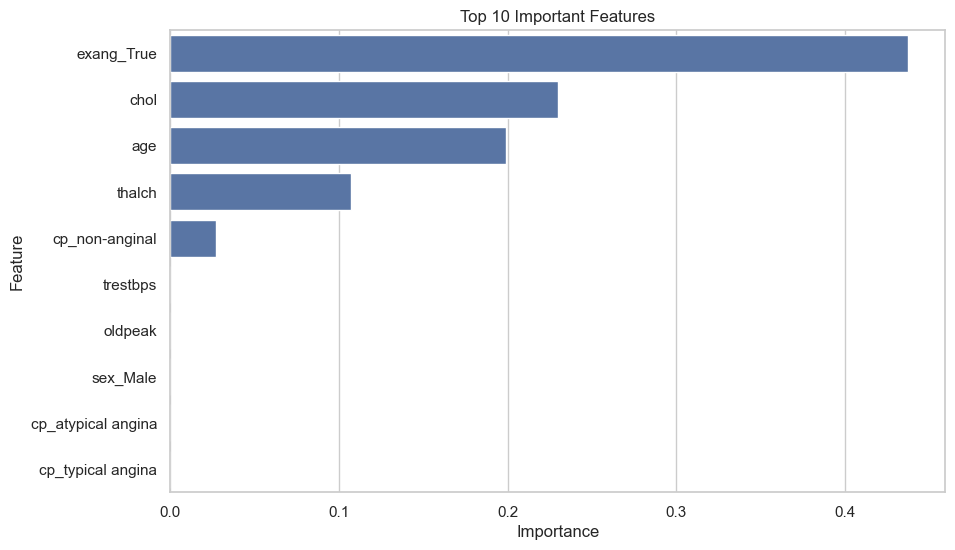

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 17. Visualize the Decision Tree

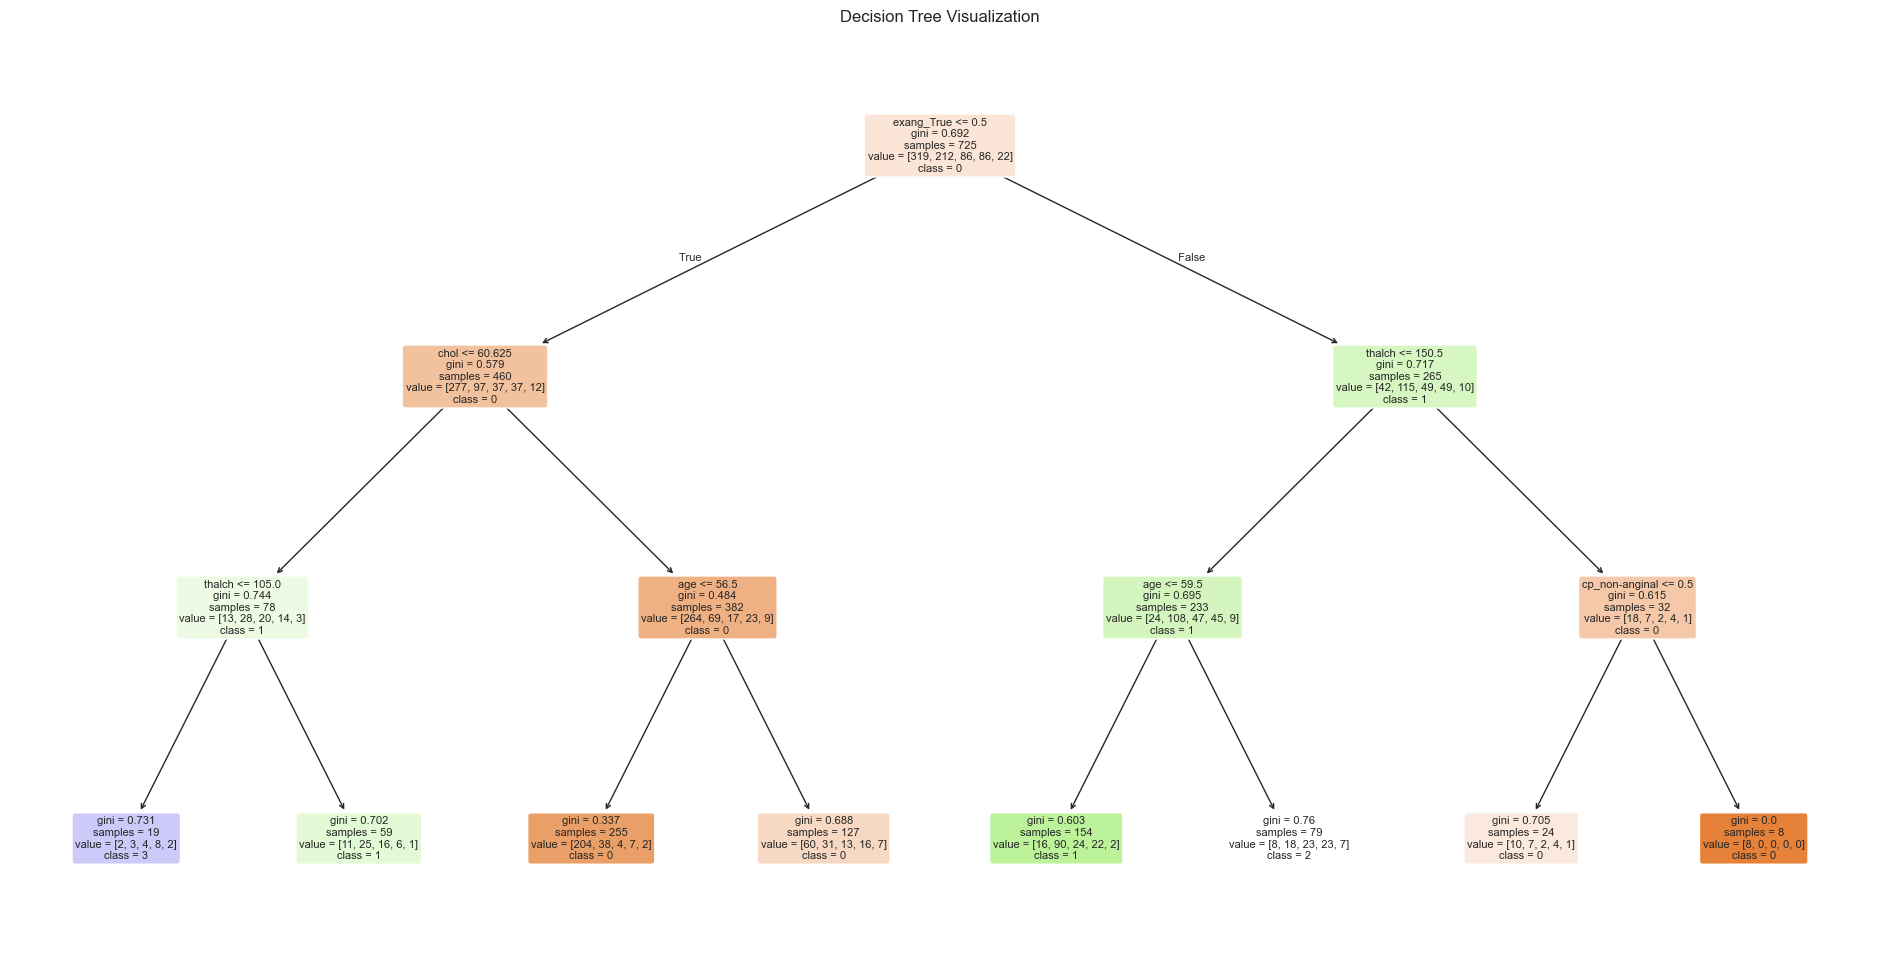

In [31]:
plt.figure(figsize=(24, 12))
plot_tree(
    best_dt_model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree Visualization')
plt.show()

## 18. Model Analysis and Interpretation

The Decision Tree classifier learned decision rules from the heart disease dataset by splitting the data based on important features. The performance was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC where possible.

**Key points:**
- Accuracy shows overall correct predictions.
- Precision shows how many predicted positive/class cases were actually correct.
- Recall shows how many actual cases were correctly detected.
- F1-score balances precision and recall.
- Feature importance helps identify the most influential variables for prediction.
- Hyperparameter tuning improves generalization and reduces overfitting.


## 19. Interview Questions

### Q1. What are some common hyperparameters of Decision Tree models, and how do they affect performance?

Common Decision Tree hyperparameters are:

1. **criterion**: It decides the quality of a split. Common values are `gini` and `entropy`.
2. **max_depth**: It controls the maximum depth of the tree. A very deep tree may overfit, while a shallow tree may underfit.
3. **min_samples_split**: It defines the minimum number of samples required to split an internal node. Higher values reduce overfitting.
4. **min_samples_leaf**: It defines the minimum number of samples required in a leaf node. Higher values make the tree more stable.
5. **max_features**: It controls how many features are considered for finding the best split.
6. **splitter**: It decides whether the model chooses the best split or a random split.

### Q2. What is the difference between Label Encoding and One-Hot Encoding?

**Label Encoding** converts categories into integer labels. Example: Male = 1, Female = 0. It is useful for ordinal categories where order matters.

**One-Hot Encoding** creates separate binary columns for each category. Example: City_Pune, City_Mumbai, City_Delhi. It is useful for nominal categories where no natural order exists.

**Main difference:** Label Encoding may introduce a false order between categories, while One-Hot Encoding avoids this by creating separate 0/1 columns.


## 20. Conclusion

In this assignment, Decision Tree Classification was applied to the heart disease dataset. The dataset was cleaned, analyzed, encoded, split into training and testing sets, and used to train a Decision Tree model. The model was evaluated using multiple metrics, and hyperparameter tuning was performed to improve performance. Feature importance and tree visualization helped interpret the model's decision-making process.

Decision Trees are easy to understand and useful for classification tasks, but they can overfit if not controlled using parameters like `max_depth`, `min_samples_split`, and `min_samples_leaf`.


## 21. Save Final Dataset with Predictions

In [32]:
# Save test predictions for submission/reference
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = best_y_pred

results.to_csv('decision_tree_predictions.csv', index=False)
print('Predictions saved as decision_tree_predictions.csv')

Predictions saved as decision_tree_predictions.csv
